# Proyecto de Extensiones de Machine Learning
# Definición del Conjunto de Datos: Agente de Inversión Adaptable

**Semana del 10 de noviembre: Entrega 1 - Descripción del Dataset**

## 1. Introducción básica al problema

El objetivo de este proyecto es diseñar un agente de inversión basado en Aprendizaje por Refuerzo (RL) con una capacidad clave: **adaptabilidad al perfil del inversor**.

A diferencia de un agente tradicional que solo busca maximizar el beneficio, nuestro modelo recibirá como entrada parámetros definidos por el usuario (ej. tolerancia al riesgo, horizonte temporal, beneficio objetivo).

Para lograr esto, el agente debe aprender a operar dentro de un entorno de simulación realista que le ofrezca oportunidades de crecimiento (`SPY`, `QQQ`) y de gestión de riesgo (`GLD`, `TLT`). El problema central no es solo "ganar dinero", sino "ganar dinero de la forma en que el usuario lo ha solicitado".

## 2. Descripción de cómo se han obtenido estos datos

Para asegurar la reproducibilidad y el realismo, el conjunto de datos no es un archivo estático. Se construye dinámicamente consultando fuentes de datos financieros públicos a través de APIs de Python.

* **Fuente Principal:** La librería `yfinance`.
* **Fuente de Características:** La librería `pandas-ta`.

El conjunto de datos se divide en dos categorías:

### Activos Comerciables (en los que el agente puede invertir)
Son los activos que el agente podrá comprar, vender o mantener.
* **`SPY`** (S&P 500): Mercado de acciones general.
* **`QQQ`** (Nasdaq 100): Sector de crecimiento y tecnología.
* **`TLT`** (Bonos del Tesoro +20a): Activo de refugio (bonos).
* **`GLD`** (Oro): Activo de refugio (materias primas).

### Sensores de Entorno (Features que el agente solo puede "leer")
Son indicadores macroeconómicos clave que el agente usará para entender el contexto del mercado, pero que no puede operar.
* **`^VIX`** (Índice de Volatilidad): "Sensor de Miedo".
* **`^TNX`** (Tasa Bonos 10a): "Sensor de Tipos de Interés".
* **`CL=F`** (Petróleo Crudo): "Sensor de Inflación / Energía".
* **`DX-Y.F`** (Índice Dólar): "Sensor de Fortaleza de la Moneda".

## 3. Tarea para la que se van a destinar

Los datos se usarán para construir un **entorno de simulación** para el agente de RL.

En cada paso (cada día), el agente recibirá un **Estado** (`State`) compuesto por:
1.  Los datos del mercado (precios e indicadores técnicos de todos los *tickers*).
2.  El estado de su portafolio (ej. % en efectivo, % en `SPY`, etc.).
3.  Los parámetros del perfil de usuario (ej. `riesgo_deseado = 'bajo'`).

El agente tomará una **Acción** (`Action`), que será la nueva distribución deseada de su portafolio (ej. "asignar 50% a `SPY`, 30% a `TLT`, 20% a efectivo").

El entorno calculará la **Recompensa** (`Reward`) basándose no solo en el beneficio/pérdida, sino en cómo de bien se alinea esa acción con el perfil de riesgo del usuario. Por ejemplo, un agente con perfil "bajo riesgo" será penalizado por asumir grandes pérdidas (alta volatilidad), aunque acabe ganando dinero.

## 4. Informe básico de estadística descriptiva

A continuación, se realiza un análisis exploratorio de todos los activos y sensores del entorno para el periodo 2010-2025.

In [ ]:
pip install pandas-ta

In [ ]:
# Importamos las librerías necesarias
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de las gráficas
sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
# 1. DEFINIR ACTIVOS Y SENSORES
tickers = [
    # Activos Comerciables
    'SPY', 'QQQ', 'GLD', 'TLT',
    # Sensores de Entorno
    '^VIX', '^TNX', 'CL=F', 'DX=F'
]

# Definimos un periodo de tiempo amplio para capturar
# diferentes ciclos de mercado
start_date = "2010-01-01"
end_date = "2025-11-15"

# 2. OBTENER DATOS
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False
)

[*********************100%***********************]  8 of 8 completed


**Nota**: El parámetro auto_adjust=True es, por defecto, el ajuste de los precios por dividendos y splits. Esto puede ser problemático para nosotros, ya que queremos los datos "crudos" y, además, ese ajuste no se aplica a índices como ^VIX o ^TNX.

**Solución**: Podemos silenciar la advertencia y hacer nuestro código más estable para todos los tipos de activos si lo desactivamos explícitamente, añadiendo auto_adjust=False.

### 4.1 Información General y Valores Nulos

Revisamos la estructura del DataFrame, el número total de ejemplos (días), el número de atributos (columnas) y la presencia de valores nulos.

In [ ]:
print("--- Información General del DataFrame ---")
# Esto nos da el número de ejemplos (filas) y atributos (columnas)
data.info()

--- Información General del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3998 entries, 2010-01-04 to 2025-11-14
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, CL=F)  3993 non-null   float64
 1   (Adj Close, DX=F)  3994 non-null   float64
 2   (Adj Close, GLD)   3993 non-null   float64
 3   (Adj Close, QQQ)   3993 non-null   float64
 4   (Adj Close, SPY)   3993 non-null   float64
 5   (Adj Close, TLT)   3993 non-null   float64
 6   (Adj Close, ^TNX)  3991 non-null   float64
 7   (Adj Close, ^VIX)  3993 non-null   float64
 8   (Close, CL=F)      3993 non-null   float64
 9   (Close, DX=F)      3994 non-null   float64
 10  (Close, GLD)       3993 non-null   float64
 11  (Close, QQQ)       3993 non-null   float64
 12  (Close, SPY)       3993 non-null   float64
 13  (Close, TLT)       3993 non-null   float64
 14  (Close, ^TNX)      3991 non-null   float64
 15  (Close, ^VIX

In [ ]:
print("\n--- Conteo de Valores Nulos por Columna ---")
# Es normal ver nulos, ya que no todos los mercados
# (ej. Acciones vs Futuros vs Bonos) operan los mismos días.
print(data.isnull().sum())


--- Conteo de Valores Nulos por Columna ---
Price      Ticker
Adj Close  CL=F      5
           DX=F      4
           GLD       5
           QQQ       5
           SPY       5
           TLT       5
           ^TNX      7
           ^VIX      5
Close      CL=F      5
           DX=F      4
           GLD       5
           QQQ       5
           SPY       5
           TLT       5
           ^TNX      7
           ^VIX      5
High       CL=F      5
           DX=F      4
           GLD       5
           QQQ       5
           SPY       5
           TLT       5
           ^TNX      7
           ^VIX      5
Low        CL=F      5
           DX=F      4
           GLD       5
           QQQ       5
           SPY       5
           TLT       5
           ^TNX      7
           ^VIX      5
Open       CL=F      5
           DX=F      4
           GLD       5
           QQQ       5
           SPY       5
           TLT       5
           ^TNX      7
           ^VIX      5
Volume     CL=F  

**Análisis de Nulos:** Se observan valores nulos. Esto es normal en datasets de múltiples activos por diferencias en festivos bursátiles o husos horarios. Para el entrenamiento del entorno, estos nulos se tratarán rellenándolos con el último valor válido (`fillna(method='ffill')`) para asegurar la continuidad de los datos.

### 4.2 Análisis de Precios de Cierre

Seleccionamos las columnas `Close` para analizar las estadísticas descriptivas y la evolución de los precios.

In [ ]:
# Seleccionamos solo las columnas 'Close'
close_prices = data['Close']

print("--- Estadísticas Descriptivas (Precios de Cierre) ---")
# Muestra media, std, min, max, etc. de cada activo/sensor
print(close_prices.describe())

--- Estadísticas Descriptivas (Precios de Cierre) ---
Ticker         CL=F         DX=F          GLD          QQQ          SPY  \
count   3993.000000  3994.000000  3993.000000  3993.000000  3993.000000   
mean      71.646852    92.666988   155.452484   204.697235   291.095532   
std       20.839649     9.292617    48.503128   148.083796   145.145866   
min      -37.630001    73.107002   100.500000    42.470001   102.199997   
25%       54.060001    82.575499   121.019997    85.410004   180.009995   
50%       71.769997    94.983501   142.509995   154.020004   256.750000   
75%       88.379997    99.099249   171.509995   314.100006   401.440002   
max      123.699997   114.046997   403.149994   635.770020   687.390015   

Ticker          TLT         ^TNX         ^VIX  
count   3993.000000  3991.000000  3993.000000  
mean     117.613236     2.592371    18.421776  
std       19.788612     0.999119     6.892725  
min       82.769997     0.499000     9.140000  
25%      101.669998     1.8495

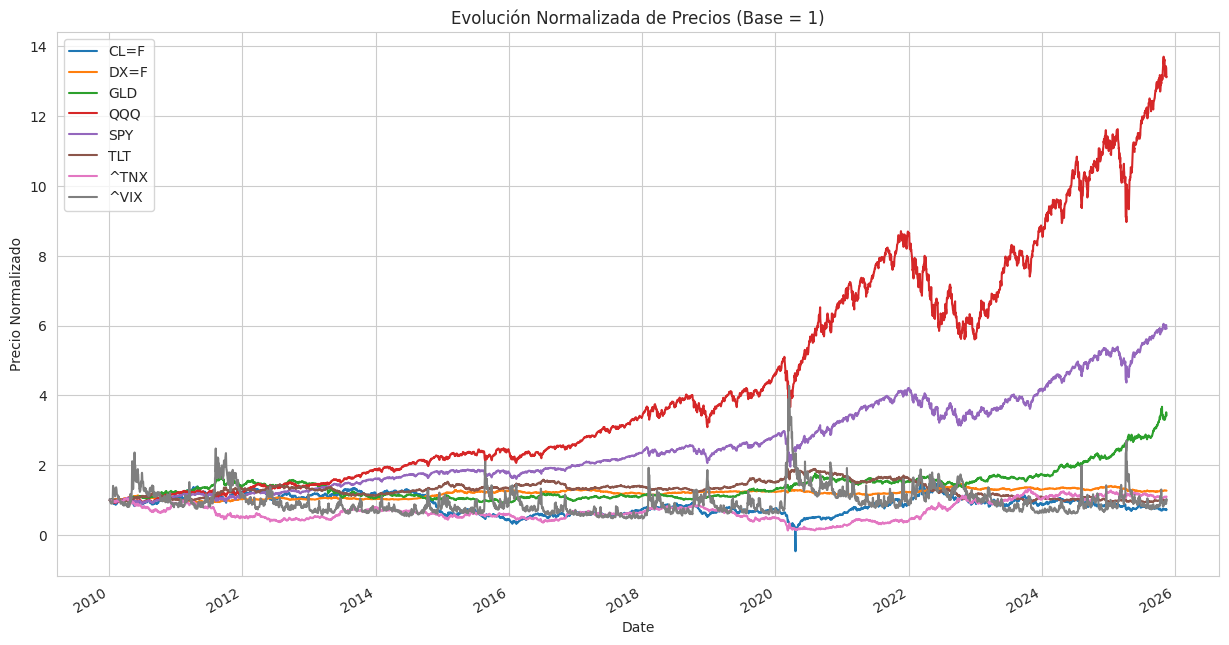

In [ ]:
# Visualización de la evolución de precios
# Usamos (precio / precio_inicial) para normalizarlos y compararlos
(close_prices / close_prices.iloc[1]).plot(figsize=(15, 8))
plt.title('Evolución Normalizada de Precios (Base = 1)')
plt.ylabel('Precio Normalizado')
plt.legend()
plt.show()

## 4.3 Estadísticas Descriptivas de los Retornos Diarios

Mientras que los precios nos dan el valor, los **retornos diarios** (cambios porcentuales) nos informan sobre la **volatilidad y el riesgo**. Este es el análisis estadístico más importante para un agente de RL, ya que su función de recompensa dependerá de la gestión de estos retornos.

In [ ]:
# 1. Calcular retornos diarios para todas las columnas de Cierre
# Ya teníamos 'close_prices' de una celda anterior
daily_returns = close_prices.pct_change().dropna()

print("--- Estadísticas Descriptivas de RETORNOS DIARIOS ---")
# .describe() nos da media, std (desviación típica) y cuantiles (25%, 50%, 75%)
print(daily_returns.describe())

--- Estadísticas Descriptivas de RETORNOS DIARIOS ---
Ticker         CL=F         DX=F          GLD          QQQ          SPY  \
count   3997.000000  3997.000000  3997.000000  3997.000000  3997.000000   
mean      -0.000683     0.000071     0.000358     0.000729     0.000505   
std        0.058310     0.004569     0.009949     0.013023     0.010895   
min       -3.059661    -0.023855    -0.087808    -0.119788    -0.109424   
25%       -0.011712    -0.002580    -0.004799    -0.004739    -0.003777   
50%        0.000821     0.000063     0.000508     0.001145     0.000643   
75%        0.012301     0.002671     0.005598     0.007298     0.005762   
max        0.376623     0.021887     0.049038     0.120031     0.105019   

Ticker          TLT         ^TNX         ^VIX  
count   3997.000000  3997.000000  3997.000000  
mean       0.000043     0.000405     0.003155  
std        0.009544     0.028025     0.082992  
min       -0.066683    -0.293201    -0.357539  
25%       -0.005782    -0.0129

/tmp/ipython-input-25238946.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = close_prices.pct_change().dropna()


### Análisis de Estadísticas (`.describe()`)

* **Media (`mean`):** Es el retorno diario promedio. Como se esperaba, es un número muy pequeño, cercano a cero, pero generalmente positivo para los activos de crecimiento (`SPY`, `QQQ`).
* **Desviación Típica (`std`):** ¡Esta es la métrica clave! Es la **definición estadística de la volatilidad (riesgo)**.
    * Podemos ver que `QQQ` (y probablemente `CL=F`) tiene un `std` más alto que `SPY`, confirmando que es más volátil.
    * `TLT` (Bonos) y `GLD` (Oro) muestran un `std` más bajo, validando su rol como activos más estables.
* **Cuantiles (`min`, `25%`, `50%`, `75%`, `max`):**
    * El `50%` (la **Mediana**) está muy cerca de 0, lo que es típico.
    * Los valores `min` y `max` nos muestran los días de pánico y euforia extremos (eventos de "cola").

### 4.4 Distribución de Retornos (Histograma y Moda)

La **Moda** (el valor más frecuente) en datos financieros no es un único número, sino un rango. La mejor forma de verlo es con un **histograma**, que nos muestra la "personalidad" del activo.

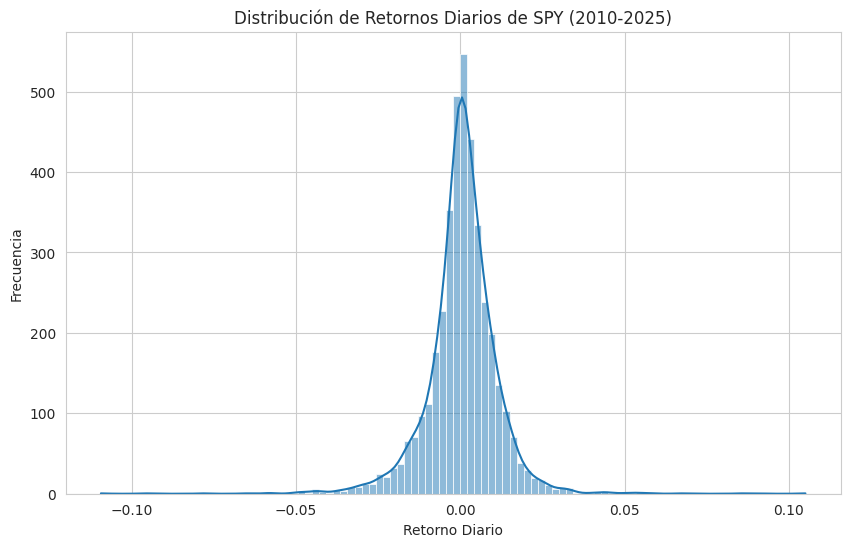

In [ ]:
# Histograma de los retornos diarios de SPY
plt.figure(figsize=(10, 6))
sns.histplot(daily_returns['SPY'], bins=100, kde=True)
plt.title('Distribución de Retornos Diarios de SPY (2010-2025)')
plt.xlabel('Retorno Diario')
plt.ylabel('Frecuencia')
plt.show()

Ya que el agente no gestionará precios, si no que gestionará riesgos, es útil hacer una medición de su volatibilidad y distribución.

Lo conseguiremos con un histograma de los retornos diarios de cada activo.

* **¿Por qué es útil?:**
  Permite ver si, por ejemplo, los retornos siguen una distribución normal.

### Análisis del Histograma:

* **Moda:** El pico central (el rango modal) está, como es de esperar, muy cerca de 0. La mayoría de los días, el mercado "no hace mucho".
* **Distribución:** La forma de campana no es perfecta. Se observa **Leptocurtosis** (un pico más alto y "colas más pesadas" que una distribución normal). Esto significa que los valores extremos (grandes caídas o subidas, en los extremos del gráfico) son **más frecuentes** de lo que un modelo estadístico simple predeciría. Esto justifica la necesidad de un agente robusto que gestione estos eventos.

Como observamos con el ejemplo de **`SPY`-**, tiene **colas pesadas** (kurtosis > 3), lo que significa que los eventos extremos (caídas y subidas masivas), son considerablemente más comunes de lo que una distribución normal esperaría.

### 4.5 Comparación de Distribuciones (Boxplots)

El **Boxplot (diagrama de caja)** es el mejor gráfico para comparar visualmente las distribuciones (cuantiles y volatilidad) de todos nuestros activos comerciables a la vez.

* La **caja** representa el Rango Intercuartílico (IQR), del cuantil 25% al 75%.
* La **línea central** es la mediana (Cuantil 50%).
* Los **"bigotes"** (líneas) muestran el rango normal de los datos.
* Los **puntos** fuera de los bigotes son los **outliers** (eventos extremos).

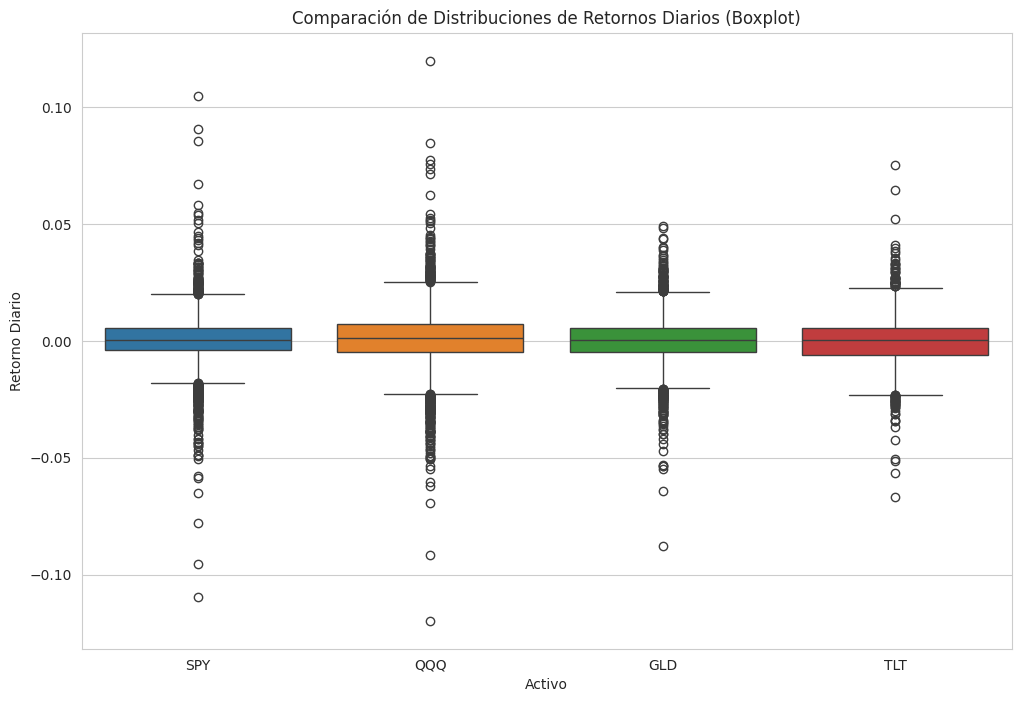

In [ ]:
# Seleccionamos solo los activos comerciables para el boxplot
tradable_assets_returns = daily_returns[['SPY', 'QQQ', 'GLD', 'TLT']]

# Boxplot para comparar distribuciones
plt.figure(figsize=(12, 8))
sns.boxplot(data=tradable_assets_returns)
plt.title('Comparación de Distribuciones de Retornos Diarios (Boxplot)')
plt.ylabel('Retorno Diario')
plt.xlabel('Activo')
plt.show()

### Análisis del Boxplot:

* **Medianas:** Todas las medianas (líneas centrales) están alineadas en 0.
* **Volatilidad (Riesgo):** El **tamaño de la caja (IQR)** es una medida visual directa de la volatilidad (`std`).
    * Se confirma visualmente que `QQQ` es el más volátil (caja más alta) de los cuatro.
    * `SPY` es el siguiente.
    * `GLD` y `TLT` son significativamente más estables (cajas más pequeñas), lo que los hace buenos candidatos para perfiles de "bajo riesgo".
* **Outliers:** Vemos que todos los activos tienen una gran cantidad de "outliers" (puntos). Esto refuerfza lo visto en el histograma: los movimientos extremos, aunque no son la norma, son una parte constante del comportamiento del mercado que el agente **debe** aprender a gestionar.

### 4.6 Matriz de Correlación

Este es el análisis más importante para validar nuestro conjunto de datos. Calculamos la correlación sobre los **cambios diarios** (`pct_change()`), no sobre los precios, ya que esto refleja la relación de movimiento *real* entre los activos y sensores.

/tmp/ipython-input-2939172052.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_changes = close_prices.pct_change().dropna()


--- Matriz de Correlación (Cambios Diarios) ---
Ticker      CL=F      DX=F       GLD       QQQ       SPY       TLT      ^TNX  \
Ticker                                                                         
CL=F    1.000000 -0.058670  0.051093  0.122153  0.160339 -0.099410  0.121697   
DX=F   -0.058670  1.000000 -0.397516 -0.145770 -0.182749 -0.062909  0.113117   
GLD     0.051093 -0.397516  1.000000  0.051481  0.049847  0.216863 -0.242872   
QQQ     0.122153 -0.145770  0.051481  1.000000  0.931079 -0.233218  0.246435   
SPY     0.160339 -0.182749  0.049847  0.931079  1.000000 -0.301123  0.323449   
TLT    -0.099410 -0.062909  0.216863 -0.233218 -0.301123  1.000000 -0.818109   
^TNX    0.121697  0.113117 -0.242872  0.246435  0.323449 -0.818109  1.000000   
^VIX   -0.121843  0.103154 -0.015991 -0.708349 -0.745850  0.235624 -0.235537   

Ticker      ^VIX  
Ticker            
CL=F   -0.121843  
DX=F    0.103154  
GLD    -0.015991  
QQQ    -0.708349  
SPY    -0.745850  
TLT     0.235624  

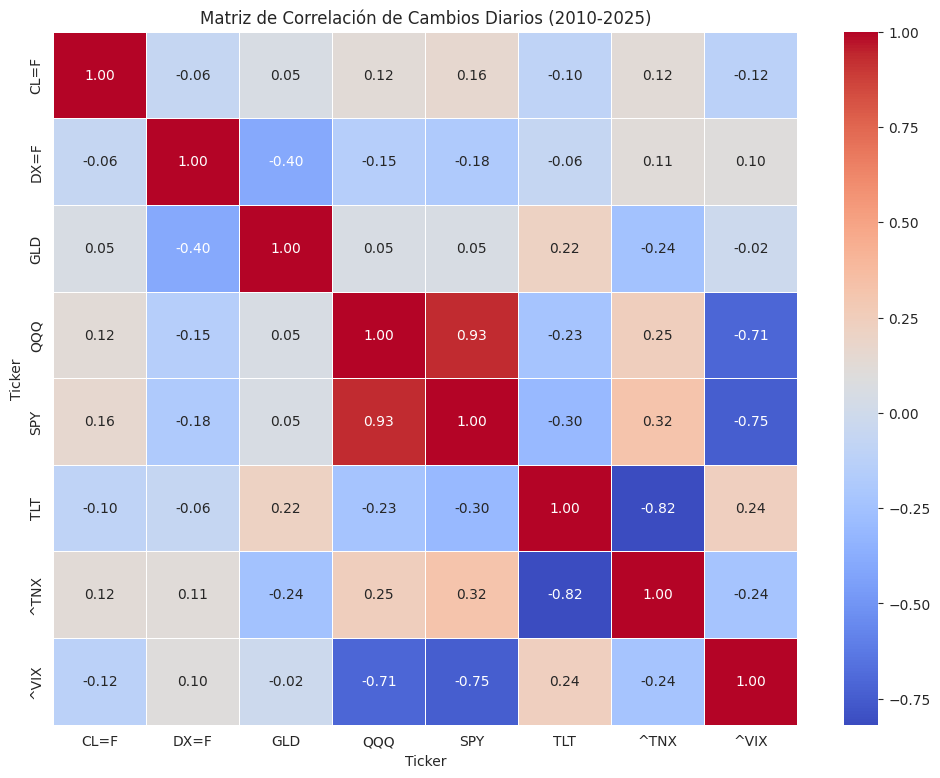

In [ ]:
# 1. Calcular cambios diarios (retornos)
# Usamos pct_change() para activos y diff() para tasas/índices,
# pero pct_change() es un buen proxy general para correlación.
daily_changes = close_prices.pct_change().dropna()

# 2. Calcular matriz de correlación
corr_matrix = daily_changes.corr()

print("--- Matriz de Correlación (Cambios Diarios) ---")
print(corr_matrix)

# 3. Visualización de la matriz
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Cambios Diarios (2010-2025)')
plt.show()

### Análisis de Correlación:

La matriz de correlación nos da una visión macroeconómica completa:

* **Activos Comerciables:**
    * **`SPY`-`QQQ`:** Alta correlación positiva (> 0.85). Esperado, ambos son acciones de EE.UU.
    * **`SPY`-`TLT` (Acciones vs Bonos):** Correlación **negativa**. Excelente. Valida `TLT` como activo de refugio.
    * **`GLD` (Oro):** Correlación muy baja (cercana a 0) con acciones y bonos. Valida su rol de diversificador.

* **Sensores y sus Relaciones Clave:**
    * **`^VIX` (Miedo):** Fuerte correlación **negativa** con `SPY` y `QQQ`. Correcto, el miedo sube cuando las acciones bajan.
    * **`^TNX` (Tipos Interés):** Correlación **negativa** con `TLT` (precios de bonos bajan si tipos suben) y `QQQ` (tecnología sufre con tipos altos).
    * **`DX-Y.F` (Dólar):** Fuerte correlación **negativa** con `GLD` (Oro). Correcto, el oro se cotiza en dólares.
    * **`CL=F` (Petróleo):** Correlación positiva con `^TNX` (petróleo alto = inflación = tipos altos).

Este conjunto de datos proporciona una visión rica y realista del entorno de mercado.

## Conclusión de la Entrega

Este conjunto de datos, compuesto por 4 activos comerciables y 4 sensores macroeconómicos, proporciona un entorno de simulación rico y realista. El análisis estadístico (especialmente la matriz de correlación) valida la elección de los *tickers* para crear un entorno donde un agente de RL puede aprender políticas de inversión complejas y, crucialmente, adaptarlas a diferentes perfiles de riesgo.

Realizado por:

  -Javier Hernández Rosique
  
  -Álvaro Espejo Martínez

***LIMPIEZA Y PREPARACIÓN DE LOS DATOS***

## 4.4 Características Adicionales (Ingeniería de Features)

Finalmente, demostramos cómo se añadirán las características técnicas (features) que el agente usará, utilizando la librería `pandas-ta`.

In [ ]:
# Crear un DataFrame de features (ej. para SPY)
spy_features = data['Close'][['SPY']].copy()

# Calcular y añadir RSI (Índice de Fuerza Relativa)
spy_features.ta.rsi(append=True)

# Calcular y añadir MACD (Moving Average Convergence Divergence)
spy_features.ta.macd(append=True)

# Calcular y añadir Bandas de Bollinger
spy_features.ta.bbands(append=True)

print("--- Ejemplo de Features para SPY (últimos 10 días) ---")
# Mostramos las últimas filas. Es normal ver NaNs al principio
# debido al período de cálculo de los indicadores (ej. 14 días para RSI)
print(spy_features.tail(10))

[X] The 'close' column was not found in: SPY
[X] The 'close' column was not found in: SPY
[X] The 'close' column was not found in: SPY
--- Ejemplo de Features para SPY (últimos 10 días) ---
Ticker             SPY
Date                  
2025-11-03  683.340027
2025-11-04  675.239990
2025-11-05  677.580017
2025-11-06  670.309998
2025-11-07  670.969971
2025-11-10  681.440002
2025-11-11  683.000000
2025-11-12  683.380005
2025-11-13  672.039978
2025-11-14  671.929993
